<a href="https://colab.research.google.com/github/Samarbal/Big-Data-Analysis/blob/main/BigDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 1 Introduction to Big Data Analysis**

In [ ]:
# import labraries
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns


## Lecture 1 :  INTRODUCTION TO BIG DATA & PYTHON BASICS


**Part 1**

**Understanding Data Scale**

In [ ]:
# Generate datasets with diffenerent sizes
def generate_data(rows):
 return pd.DataFrame({
 'user_id': np.random.randint(1, 1000, rows),
 'product_id': np.random.randint(1, 500, rows),
 'quantity': np.random.randint(1, 10, rows),
 'price': np.random.uniform(10, 1000, rows),
 'timestamp': pd.date_range('2024-01-01', periods=rows, freq='1min')
 })
# Test different data sizes
sizes = [1000, 10000, 100000, 1000000]
processing_times = []
for size in sizes:
  df = generate_data(size)

  start = time.time()
  # Simple aggregation
  result = df.groupby('product_id')['quantity'].sum()
  end = time.time()

  processing_times.append(end - start)

  print(f"Size: {size:,} rows | Time: {end-start:.4f} seconds | Memory: {df.memory_usage().sum() / 1024**2:.2f} MB")


Size: 1,000 rows | Time: 0.0291 seconds | Memory: 0.04 MB
Size: 10,000 rows | Time: 0.0010 seconds | Memory: 0.38 MB
Size: 100,000 rows | Time: 0.0024 seconds | Memory: 3.81 MB
Size: 1,000,000 rows | Time: 0.0291 seconds | Memory: 38.15 MB


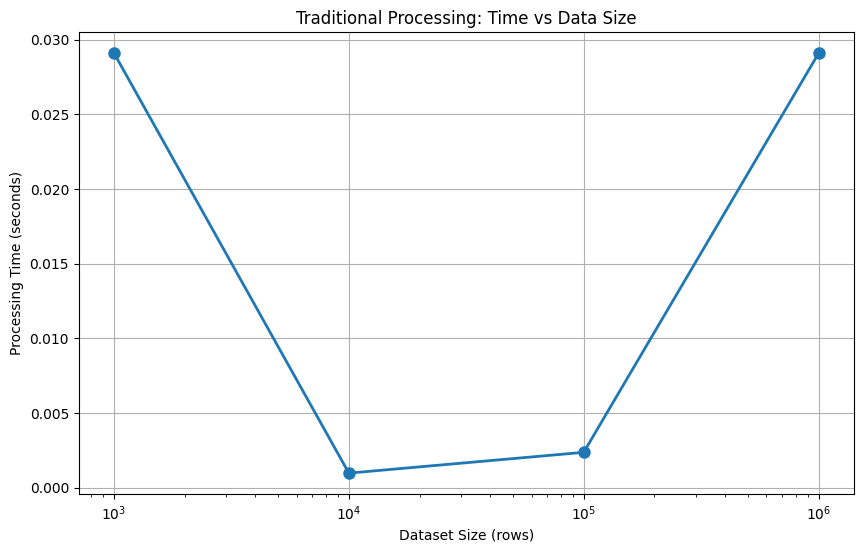

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
plt.plot(sizes, processing_times, marker='o', linewidth=2, markersize=8)
plt.xlabel('Dataset Size (rows)')
plt.ylabel('Processing Time (seconds)')
plt.title('Traditional Processing: Time vs Data Size')
plt.grid(True)
plt.xscale('log')
plt.show()

**Part 2**

**The 5 V's in Practice**

In [ ]:
# Volume: Generate large dataset
large_data = generate_data(500000)
print(f"Volume: {large_data.shape[0]:,} rows, {large_data.memory_usage().sum() / 1024**2:.2f} MB")


Volume: 500,000 rows, 19.07 MB


In [ ]:
# Velocity: Simulate streaming data
print("\n--- Simulating Data Velocity ---")
for i in range(5):
 batch = generate_data(10000)
 print(f"Batch {i+1}: Received {len(batch)} records at {pd.Timestamp.now()}")
 time.sleep(1)


--- Simulating Data Velocity ---
Batch 1: Received 10000 records at 2026-04-18 08:21:41.286368
Batch 2: Received 10000 records at 2026-04-18 08:21:42.288431
Batch 3: Received 10000 records at 2026-04-18 08:21:43.290363
Batch 4: Received 10000 records at 2026-04-18 08:21:44.292308
Batch 5: Received 10000 records at 2026-04-18 08:21:45.294427


In [ ]:
# Variety: Multiple data types
variety_data = {
 'structured': large_data,
 'semi_structured': {
 'users': [{'id': 1, 'name': 'Ahmed', 'purchases': [101, 102]},
 {'id': 2, 'name': 'Sara', 'purchases': [103]}],
 },
 'unstructured': ['Customer review text here', 'Another review']
}
print(f"\n--- Data Variety ---")
print(f"Structured: DataFrame with {len(variety_data['structured'])} rows")
print(f"Semi-structured: JSON with {len(variety_data['semi_structured']['users'])} users")
print(f"Unstructured: {len(variety_data['unstructured'])} text documents")


--- Data Variety ---
Structured: DataFrame with 500000 rows
Semi-structured: JSON with 2 users
Unstructured: 2 text documents


In [ ]:
# Veracity: Data quality issues
print("\n--- Data Veracity Issues ---")
# Inject quality problems
large_data.loc[100:110, 'price'] = np.nan # Missing values
large_data.loc[200:205, 'quantity'] = -5 # Invalid values
large_data = pd.concat([large_data, large_data.iloc[:100]]) # Duplicates
print(f"Missing values: {large_data.isnull().sum().sum()}")
print(f"Invalid quantities: {(large_data['quantity'] < 0).sum()}")
print(f"Duplicate rows: {large_data.duplicated().sum()}")


--- Data Veracity Issues ---
Missing values: 11
Invalid quantities: 6
Duplicate rows: 100


In [ ]:

# Value: Extract insights
print("\n--- Extracting Value ---")
total_revenue = (large_data['quantity'] * large_data['price']).sum()
top_products = large_data.groupby('product_id')['quantity'].sum().nlargest(5)
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"\nTop 5 Products:")
print(top_products)


--- Extracting Value ---
Total Revenue: $1,261,558,028.06

Top 5 Products:
product_id
420    5494
214    5414
395    5399
442    5399
41     5397
Name: quantity, dtype: int64


**Part 3**

**When Do We Need Big Data?**

In [ ]:
# Scenario comparison
print("=== SCENARIO 1: Small Data (Excel is enough) ===")
small_data = generate_data(1000)
print(f"Size: {len(small_data)} rows")
print(f"Can open in Excel: YES ✓")
print(f"Pandas processing time: {0.01:.4f} seconds")
print("\n=== SCENARIO 2: Medium Data (Pandas works) ===")
medium_data = generate_data(100000)
print(f"Size: {len(medium_data)} rows")
print(f"Can open in Excel: NO ✗ (Excel limit: ~1M rows)")
print(f"Pandas processing time: ~0.1 seconds")
print("\n=== SCENARIO 3: Big Data (Need distributed systems) ===")
print(f"Estimated size: 100,000,000 rows (100M)")
print(f"Estimated memory: ~7.5 GB")
print(f"Pandas: Will crash on most laptops ✗")
print(f"Need: Hadoop/Spark ✓")
print(f"Estimated Spark processing time: ~10 seconds on 10-node cluster")

=== SCENARIO 1: Small Data (Excel is enough) ===
Size: 1000 rows
Can open in Excel: YES ✓
Pandas processing time: 0.0100 seconds

=== SCENARIO 2: Medium Data (Pandas works) ===
Size: 100000 rows
Can open in Excel: NO ✗ (Excel limit: ~1M rows)
Pandas processing time: ~0.1 seconds

=== SCENARIO 3: Big Data (Need distributed systems) ===
Estimated size: 100,000,000 rows (100M)
Estimated memory: ~7.5 GB
Pandas: Will crash on most laptops ✗
Need: Hadoop/Spark ✓
Estimated Spark processing time: ~10 seconds on 10-node cluster
